**Recovery note:** This notebook was reconstructed from an HTML export. The code, narrative, and visible outputs were preserved where possible.


<h1 id="EDA-Summary">EDA Summary<a class="anchor-link" href="#EDA-Summary">¶</a></h1>


In [79]:
# Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot colours
BLACK = "#111111"
SKY_BLUE = "#3FA9E2"

# Global plot style
sns.set_theme(style="white")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": BLACK,
    "axes.labelcolor": BLACK,
    "axes.titlecolor": BLACK,
    "xtick.color": BLACK,
    "ytick.color": BLACK,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "axes.grid": False,
    "font.size": 11
})


<h2 id="Datasets-Overview">Datasets Overview<a class="anchor-link" href="#Datasets-Overview">¶</a></h2>


In [111]:
# Load datasets
DATA_PATH = Path("../data/raw")

positions_part1 = pd.read_csv(DATA_PATH / "vessel_positions_part1.csv")
positions_part2 = pd.read_csv(DATA_PATH / "vessel_positions_part2.csv")
tracks = pd.read_csv(DATA_PATH / "vessel_tracks.csv")


print(f"Positions Part 1: {positions_part1.shape}")
print(f"Positions Part 2: {positions_part2.shape}")
print(f"Tracks          : {tracks.shape}")


Positions Part 1: (767105, 17)
Positions Part 2: (767105, 17)
Tracks          : (1196, 24)


In [81]:
print(positions_part2.columns)
positions_part2.head()


Index(['id', 'mmsi', 'name', 'category', 'nav_status', 'nav_status_str', 'sog',
       'cog', 'heading', 'lat', 'lon', 'destination', 'draught',
       'manoeuvre_str', 'recorded_at', 'created_at', 'updated_at'],
      dtype='str')


,id,mmsi,name,category,nav_status,nav_status_str,sog,cog,heading,lat,lon,destination,draught,manoeuvre_str,recorded_at,created_at,updated_at
0,767106,992476135,8^ MRSC RAVENNA,aton,NaN,—,NaN,NaN,NaN,44.4953,12.2810,NaN,NaN,—,2026-04-09 19:57:18,2026-04-09 19:57:18,2026-04-09 19:57:18
1,767107,992476127,1^ MRSC GENOA,aton,NaN,—,NaN,NaN,NaN,44.4080,8.9231,NaN,NaN,—,2026-04-09 19:57:18,2026-04-09 19:57:18,2026-04-09 19:57:18
2,767108,992476139,12^ MRSC PALERMO,aton,NaN,—,NaN,NaN,NaN,38.1250,13.3642,NaN,NaN,—,2026-04-09 19:57:18,2026-04-09 19:57:18,2026-04-09 19:57:18
3,767109,992476129,3^ MRSC CIVITAVECCHI,aton,NaN,—,NaN,NaN,NaN,41.7705,12.2303,NaN,NaN,—,2026-04-09 19:57:18,2026-04-09 19:57:18,2026-04-09 19:57:18
4,767110,992476131,5^ MRSC REGGIO CALAB,aton,NaN,—,NaN,NaN,NaN,38.1296,15.6524,NaN,NaN,—,2026-04-09 19:57:18,2026-04-09 19:57:18,2026-04-09 19:57:18


In [82]:
print(tracks.columns)
tracks.head()


Index(['id', 'mmsi', 'category', 'name', 'callsign', 'flag', 'ship_type',
       'ship_type_str', 'nav_status', 'nav_status_str', 'sog', 'cog',
       'heading', 'lat', 'lon', 'destination', 'eta', 'dimensions', 'draught',
       'manoeuvre_str', 'msg_count', 'last_update', 'created_at',
       'updated_at'],
      dtype='str')


,id,mmsi,category,name,callsign,flag,ship_type,ship_type_str,nav_status,nav_status_str,sog,cog,heading,lat,lon,destination,eta,dimensions,draught,manoeuvre_str,msg_count,last_update,created_at,updated_at
0,1,374818000,ship,NaN,NaN,Panama 🇵🇦,NaN,—,0.0,In navigazione a motore ⚙️,9.9,179.2,511.0,36.987062,15.455843,NaN,NaN,NaN,NaN,Non disponibile,1,2026-04-03 22:48:51,2026-04-03 10:37:31,2026-04-03 22:49:15
1,2,235098095,ship,MOONDANCE,2GKD3,Regno Unito 🇬🇧,36.0,Barca a vela ⛵,NaN,—,6.0,7.2,511.0,37.576037,15.202413,NaN,NaN,NaN,NaN,—,363,2026-04-06 13:11:12,2026-04-03 10:37:31,2026-04-06 13:11:38
2,3,240788000,ship,MINERVA JOANNA,SVAB9,Grecia 🇬🇷,80.0,Petroliera/Tanker 🛢️,0.0,In navigazione a motore ⚙️,12.7,97.1,94.0,37.214147,15.745027,PIRAEUS,04/05 07:00,183m × 32m,8.0,Non disponibile,1363,2026-04-03 14:56:11,2026-04-03 10:37:31,2026-04-03 14:57:10
3,4,351222000,ship,NaN,NaN,Panama 🇵🇦,NaN,—,0.0,In navigazione a motore ⚙️,5.4,268.8,260.0,36.742688,16.653983,NaN,NaN,NaN,NaN,Non disponibile,2,2026-04-13 16:45:33,2026-04-03 10:37:31,2026-04-13 16:46:15
4,5,247427400,ship,BEPPE,IQJB,Italia 🇮🇹,52.0,Rimorchiatore,5.0,Ormeggiata 🔗,0.0,75.1,511.0,37.498677,15.095497,IT CTA,03/25 15:00,30m × 10m,4.2,Non disponibile,1923,2026-04-16 15:39:14,2026-04-03 10:37:31,2026-04-16 15:39:14


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>The two Positions datasets contains  AIS messages recorded at different points in time.</li>
<li>Both position files have the same number of columns and appear to be parts of the same dataset. (can be combined)</li>
<li>The Tracks dataset contains vessel level information, each row represents one vessel.</li>
</ul>


<h2 id="Missing-Values-and-Duplicates">Missing Values and Duplicates<a class="anchor-link" href="#Missing-Values-and-Duplicates">¶</a></h2>


In [112]:
datasets = {
    "Positions Part 1": positions_part1,
    "Positions Part 2": positions_part2,
    "Tracks": tracks
}

for name, df in datasets.items():

    missing = (
        pd.DataFrame({
            "Missing (%)": (df.isna().mean() * 100).round(2)
        })
        .query("`Missing (%)` > 0")
        .sort_values("Missing (%)", ascending=False)
    )

    print("=" * 60)
    print(name)
    print("=" * 60)
    display(missing)

    print(f"Duplicate rows: {df.duplicated().sum():,}")


Positions Part 1


,Missing (%)
destination,55.11
draught,52.83
nav_status,43.66
heading,39.20
sog,39.17
cog,39.17
name,9.66


Duplicate rows: 0
Positions Part 2


,Missing (%)
destination,48.41
draught,46.42
nav_status,37.49
heading,34.47
cog,34.36
sog,34.35
name,9.40


Duplicate rows: 0
Tracks


,Missing (%)
destination,63.55
dimensions,62.37
eta,62.37
draught,62.37
callsign,58.61
ship_type,58.44
name,54.35
nav_status,10.87
heading,5.27
cog,4.93


Duplicate rows: 0


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>The two Positions datasets look identical in terms of structure and have similar missing-value pattern</li>
<li>No duplicate rows were found.</li>
<li>The main missing values in the Positions data are destination, draught, navigation status, heading, speed, and course.</li>
<li>The Tracks dataset has more missing metadata than the Positions datasets, particularly for destination, ETA, dimensions, draught, callsign, and ship type.</li>
</ul>


<h2 id="Merging-the-2-datasets-of-positions">Merging the 2 datasets of positions<a class="anchor-link" href="#Merging-the-2-datasets-of-positions">¶</a></h2>


In [117]:
positions_part1.columns.equals(positions_part2.columns)


True


In [118]:
positions = pd.concat(
    [positions_part1, positions_part2],
    ignore_index=True
)

print(f"Merged dataset shape: {positions.shape}")
print(f"Duplicate rows: {positions.duplicated().sum()}")


Merged dataset shape: (1534210, 17)
Duplicate rows: 0


<h2 id="Categorical-Variable">Categorical Variable<a class="anchor-link" href="#Categorical-Variable">¶</a></h2>


In [120]:
datasets = {
    "Positions": positions,
    "Tracks": tracks
}

summary = []

for name, df in datasets.items():

    categorical_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns

    for col in categorical_cols:
        summary.append({
            "Dataset": name,
            "Feature": col,
            "Unique Categories": df[col].nunique(dropna=True),
            "Missing (%)": round(df[col].isna().mean() * 100, 2)
        })

categorical_summary = (
    pd.DataFrame(summary)
    .sort_values(["Dataset", "Unique Categories"])
    .reset_index(drop=True)
)

display(categorical_summary)


,Dataset,Feature,Unique Categories,Missing (%)
0,Positions,category,3,0.00
1,Positions,manoeuvre_str,4,0.00
2,Positions,nav_status_str,12,0.00
3,Positions,destination,523,51.76
4,Positions,name,907,9.53
5,Positions,recorded_at,16927,0.00
6,Positions,created_at,23361,0.00
7,Positions,updated_at,23361,0.00
8,Tracks,category,3,0.00
9,Tracks,manoeuvre_str,4,0.00


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><p><em>destination</em>, <em>name</em> contain many unique values and will require special handling during preprocessing. Other columns like "last updated at" and "eta" will be converted to datetype</p>


<h2 id="1.5-Vessel-Types">1.5 Vessel Types<a class="anchor-link" href="#1.5-Vessel-Types">¶</a></h2><p><strong>Question:</strong> What are the most common vessel types in the dataset?</p>
<p><em>ship_type_str</em></p>


In [121]:
tracks["ship_type_str"].value_counts(dropna=False).head(20)


ship_type_str
—                               653
Cargo 📦                         140
Petroliera/Tanker 🛢️             93
Cargo — Hazardous cat. A         39
Barca a vela ⛵                   33
Tanker — No info                 30
Cargo — No info                  27
Punto di riferimento fisso 📍     17
Tanker — Hazardous cat. A        17
Rimorchiatore                    16
AtoN (default)                   11
Tanker — Hazardous cat. B        11
Imbarcazione da diporto          11
Passeggeri 🚢                     11
Pesca 🎣                          10
Boa cardinale S 🔶                 9
Tanker — Hazardous cat. D         8
Cargo — Hazardous cat. C          8
Non disponibile                   8
Cargo — Hazardous cat. D          7
Name: count, dtype: int64


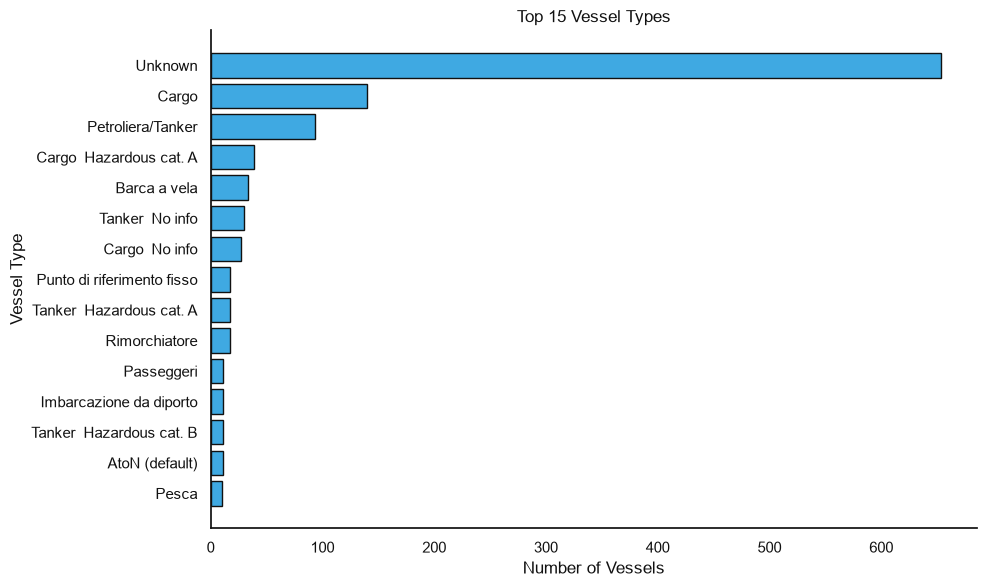

In [122]:
ship_type_clean = (
    tracks["ship_type_str"]
    .replace("—", "Unknown")
    .str.replace(r"[^\x00-\x7F]+", "", regex=True)  # Remove emojis/symbols
    .str.strip()
)

ship_types = (
    ship_type_clean
    .value_counts()
    .head(15)
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    ship_types.index,
    ship_types.values,
    color=SKY_BLUE,
    edgecolor=BLACK
)

plt.title("Top 15 Vessel Types")
plt.xlabel("Number of Vessels")
plt.ylabel("Vessel Type")

plt.tight_layout()
plt.show()


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><p>We can see that the largest group of vessels has an unknown type. Then, cargo and tanker vessels are the most common,</p>


<h2 id="Vessel-Navigation-Status">Vessel Navigation Status<a class="anchor-link" href="#Vessel-Navigation-Status">¶</a></h2><p><em>nav_status_str</em></p>
<p><strong>Question:</strong> Are the vessels moving, anchored, or moored?</p>


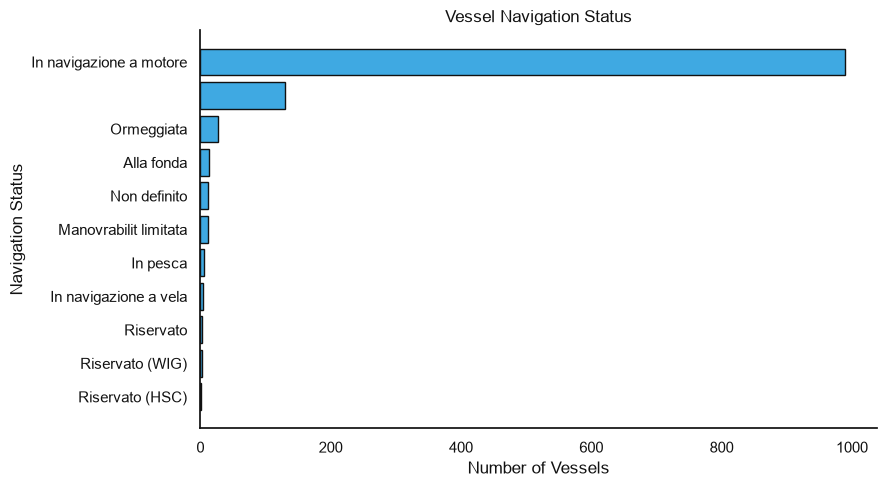

In [125]:
nav_status = (
    tracks["nav_status_str"]
    .replace("--", np.nan)
    .dropna()
    .str.replace(r"[^\x00-\x7F]+", "", regex=True)
    .str.strip()
    .value_counts()
    .sort_values()
)

plt.figure(figsize=(9, 5))

plt.barh(
    nav_status.index,
    nav_status.values,
    color=SKY_BLUE,
    edgecolor=BLACK
)

plt.title("Vessel Navigation Status")
plt.xlabel("Number of Vessels")
plt.ylabel("Navigation Status")

plt.tight_layout()
plt.show()


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>Most vessels are recorded as <strong>In navigazione a motore (moving under engine power)</strong>.</li>
<li>Smaller numbers of vessels are <strong>Ormeggiata (moored)</strong>, <strong>Alla fonda (at anchor)</strong>, <strong>In pesca (fishing)</strong>, or <strong>In navigazione a vela (under sail)</strong>.</li>
<li>Most vessels are actively moving.</li>
</ul>
<p><strong>Note:</strong></p>
<ul>
<li><strong>Moored</strong> = tied to a dock, pier, or buoy.</li>
<li><strong>At anchor</strong> = stationary using an anchor instead of being tied to a dock.</li>
</ul>


<h2 id="Speed-Over-Ground-(sog)">Speed Over Ground (sog)<a class="anchor-link" href="#Speed-Over-Ground-(sog)">¶</a></h2><p><em>Vessel speed</em></p>
<p><strong>Question:</strong> How fast are vessels travelling according to the recorded AIS data?</p>


In [128]:
print("Speed Summary")

print(f"\nMessages at 0 knots: {positions['sog'].eq(0).mean() * 100:.1f}%")

display(
    positions["sog"]
    .quantile([0.95, 0.99, 0.999])
    .rename("Speed (knots)")
)

print(f"\nMaximum recorded speed: {positions['sog'].max():.1f} knots")


Speed Summary

Messages at 0 knots: 30.0%


0.950    13.9
0.990    17.9
0.999    21.0
Name: Speed (knots), dtype: float64



Maximum recorded speed: 1023.0 knots


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>Around <strong>30%</strong> of AIS messages are recorded at <strong>0 knots</strong>, indicating stationary vessels.</li>
<li><strong>95%</strong> of recorded speeds are below <em>13.9 knots</em>, while <em>99%</em> are below <em>17.9 knots</em>.</li>
<li>The maximum recorded speed (<em>1023 knots</em>) is an AIS placeholder value and will be handled during preprocessing.</li>
</ul>
<p><strong>Note:</strong> <strong>Speed Over Ground (SOG)</strong> is the vessel's speed over the Earth's surface, measured in <strong>knots</strong>.</p>


<h2 id="Course-Over-Ground-(cog)">Course Over Ground (cog)<a class="anchor-link" href="#Course-Over-Ground-(cog)">¶</a></h2><p><em>Vessel course</em></p>
<p><strong>Question:</strong> In which directions are vessels travelling according to the recorded AIS data?
COG (Course Over Ground) = Where the vessel is actually moving.</p>


In [129]:
print("Course Over Ground (COG) Summary")

display(positions["cog"].describe().round(1))


Course Over Ground (COG) Summary


count    970229.0
mean        202.9
std         112.5
min           0.0
25%         101.6
50%         210.9
75%         296.0
max         360.0
Name: cog, dtype: float64


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>Vessel courses cover the full range from <strong>0° to 360°</strong>, showing that vessels travel in all directions.</li>
<li>No obvious invalid values were observed.</li>
<li><strong>COG</strong> appears to be a useful feature for ETA prediction.</li>
</ul>
<p><strong>Note:</strong> <strong>Course Over Ground (COG)</strong> is the direction in which a vessel is moving, measured from <strong>0° to 360°</strong> clockwise from true north.</p>


<h2 id="Heading">Heading<a class="anchor-link" href="#Heading">¶</a></h2><p><em>heading</em></p>
<p><strong>Question:</strong> Are there any unusual heading values recorded in the dataset?
Heading = Where the front (bow) of the vessel is pointing.</p>


In [130]:
print("Heading Summary")

display(
    positions["heading"]
    .describe()
    .round(1)
)

print(f"\nMaximum recorded heading: {positions['heading'].max():.0f}°")

print("\nMost common heading values")

display(
    positions["heading"]
    .value_counts()
    .head(10)
)


Heading Summary


count    969074.0
mean        256.5
std         175.9
min           0.0
25%          95.0
50%         228.0
75%         511.0
max         511.0
Name: heading, dtype: float64



Maximum recorded heading: 511°

Most common heading values


heading
511.0    256354
180.0     16116
84.0      10059
92.0       9189
94.0       8210
57.0       8174
50.0       7929
85.0       7873
93.0       7833
153.0      7237
Name: count, dtype: int64


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>Most heading values fall within the expected range of <strong>0° to 360°</strong>.</li>
<li>The value <strong>511</strong> is the most common heading and is an AIS placeholder rather than a valid measurement.</li>
<li>This placeholder will be replaced with missing values during preprocessing.</li>
</ul>
<p><strong>Note:</strong> <strong>Heading</strong> is the direction the front (bow) of the vessel is pointing.</p>


<h2 id="AIS-Recording-Time-(recorded_at)">AIS Recording Time (<code>recorded_at</code>)<a class="anchor-link" href="#AIS-Recording-Time-(recorded_at)">¶</a></h2><p><strong>Question:</strong> What time period does the dataset cover, and how are AIS messages distributed over time?</p>


In [132]:
positions["recorded_at"] = pd.to_datetime(
    positions["recorded_at"],
    errors="coerce"
)

print("Observation Period")
print(f"First AIS message: {positions['recorded_at'].min()}")
print(f"Last AIS message:  {positions['recorded_at'].max()}")

messages_per_day = (
    positions
    .groupby(positions["recorded_at"].dt.date)
    .size()
    .rename("AIS Messages")
)

display(messages_per_day.to_frame())


Observation Period
First AIS message: 2026-04-03 10:42:38
Last AIS message:  2026-04-16 12:43:53


,AIS Messages
recorded_at,
2026-04-03,63141
2026-04-04,102447
2026-04-05,106678
2026-04-06,124025
2026-04-07,133872
2026-04-08,136568
2026-04-09,121017
2026-04-10,147887
2026-04-11,150470


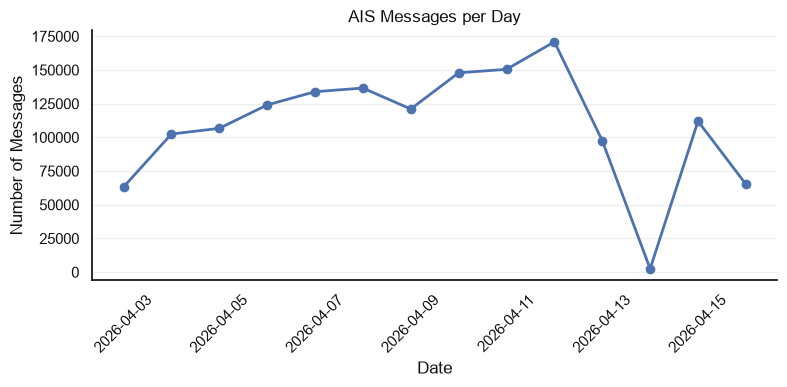

In [134]:
plt.figure(figsize=(8, 4))

plt.plot(
    messages_per_day.index,
    messages_per_day.values,
    marker="o",
    linewidth=2
)

plt.title("AIS Messages per Day")
plt.xlabel("Date")
plt.ylabel("Number of Messages")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>The dataset covers <strong>3 April 2026</strong> to <strong>16 April 2026</strong>.</li>
<li>Most days contain a relatively consistent number of AIS messages.</li>
<li><strong>3 April</strong>, <strong>14 April</strong> contain fewer AIS messages because only part of each day was recorded.</li>
<li><strong>16 April</strong> could also a partial day.</li>
</ul>


<h2 id="1.11-AIS-Messages-per-Vessel">1.11 AIS Messages per Vessel<a class="anchor-link" href="#1.11-AIS-Messages-per-Vessel">¶</a></h2><p><em>mmsi</em></p>
<p><strong>Question:</strong> How many AIS messages are available for each vessel?</p>


In [136]:
print("AIS Messages per Vessel")

display(
    messages_per_vessel
    .describe()
    .rename("Messages")
    .round(1)
)

print(f"\nUnique vessels: {messages_per_vessel.count():,}")
print(f"Maximum messages for one vessel: {messages_per_vessel.max():,}")


AIS Messages per Vessel


count     1178.0
mean      1302.4
std       3233.9
min          8.0
25%         89.0
50%        245.5
75%        549.5
max      16924.0
Name: Messages, dtype: float64



Unique vessels: 1,178
Maximum messages for one vessel: 16,924


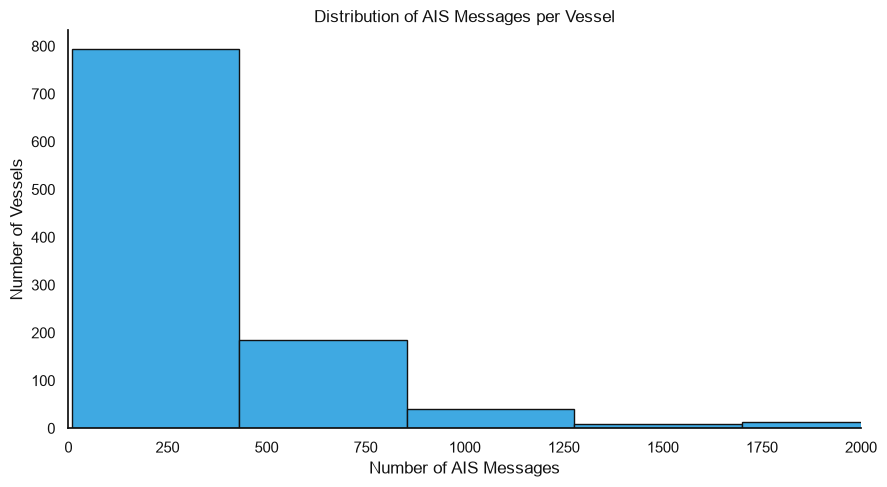

In [110]:
plt.figure(figsize=(9,5))

plt.hist(
    messages_per_vessel,
    bins=40,
    color=SKY_BLUE,
    edgecolor=BLACK
)

plt.xlim(0, 2000)

plt.title("Distribution of AIS Messages per Vessel")
plt.xlabel("Number of AIS Messages")
plt.ylabel("Number of Vessels")

plt.tight_layout()
plt.show()


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>The dataset contains AIS messages from <strong>1,178</strong> unique vessels.</li>
<li>The number of messages per vessel ranges from <strong>8</strong> to <strong>16,924</strong>.</li>
<li>Most vessels have relatively few messages, while a small number contribute much larger amounts of data.</li>
</ul>


<h2 id="1.12-Dataset-Consistency-Check">1.12 Dataset Consistency Check<a class="anchor-link" href="#1.12-Dataset-Consistency-Check">¶</a></h2><p><strong>Question:</strong> Are the vessels in the Tracks dataset also present in the Positions dataset?</p>


In [142]:
tracks_vessels = tracks["mmsi"].nunique()
positions_vessels = positions["mmsi"].nunique()

missing_tracks = tracks[
    ~tracks["mmsi"].isin(positions["mmsi"])
]

print("Dataset Comparison")
print(f"Unique vessels in Tracks:    {tracks_vessels}")
print(f"Unique vessels in Positions: {positions_vessels}")
print(f"Vessels only in Tracks:      {len(missing_tracks)}")


Dataset Comparison
Unique vessels in Tracks:    1196
Unique vessels in Positions: 1178
Vessels only in Tracks:      18


<h3 id="Findings">Findings<a class="anchor-link" href="#Findings">¶</a></h3><ul>
<li>The <strong>Tracks</strong> dataset contains <strong>1,196</strong> vessels, while <strong>Positions</strong> contains <strong>1,178</strong>.</li>
<li><strong>18</strong> vessels appear only in the Tracks dataset.</li>
<li>They have little or no AIS position data and appear to be incomplete records.</li>
<li>they can be removed without affecting ETA prediction</li>
</ul>
